In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import Rectangle
import seaborn as sns

In [3]:
traces = pd.read_csv("traces.dat", delimiter="\t")

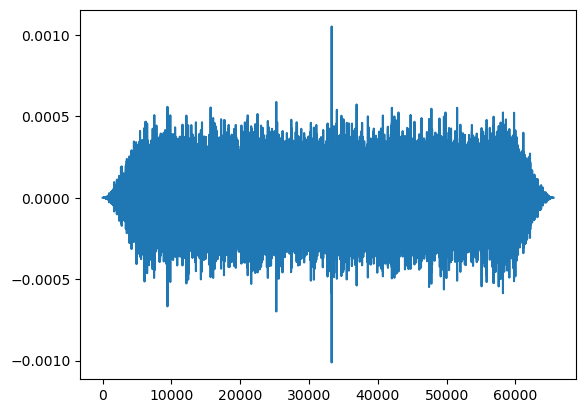

In [4]:
plt.plot(traces)
plt.show()

In [5]:
traces[6000:]

,-1.103365106272696675e-09
6000,8.161576e-05
6001,-1.292752e-04
6002,-2.272091e-05
6003,5.165838e-05
6004,-3.896804e-05
...,...
65530,-1.191121e-09
65531,-2.265863e-09
65532,9.414892e-10
65533,-4.467004e-10


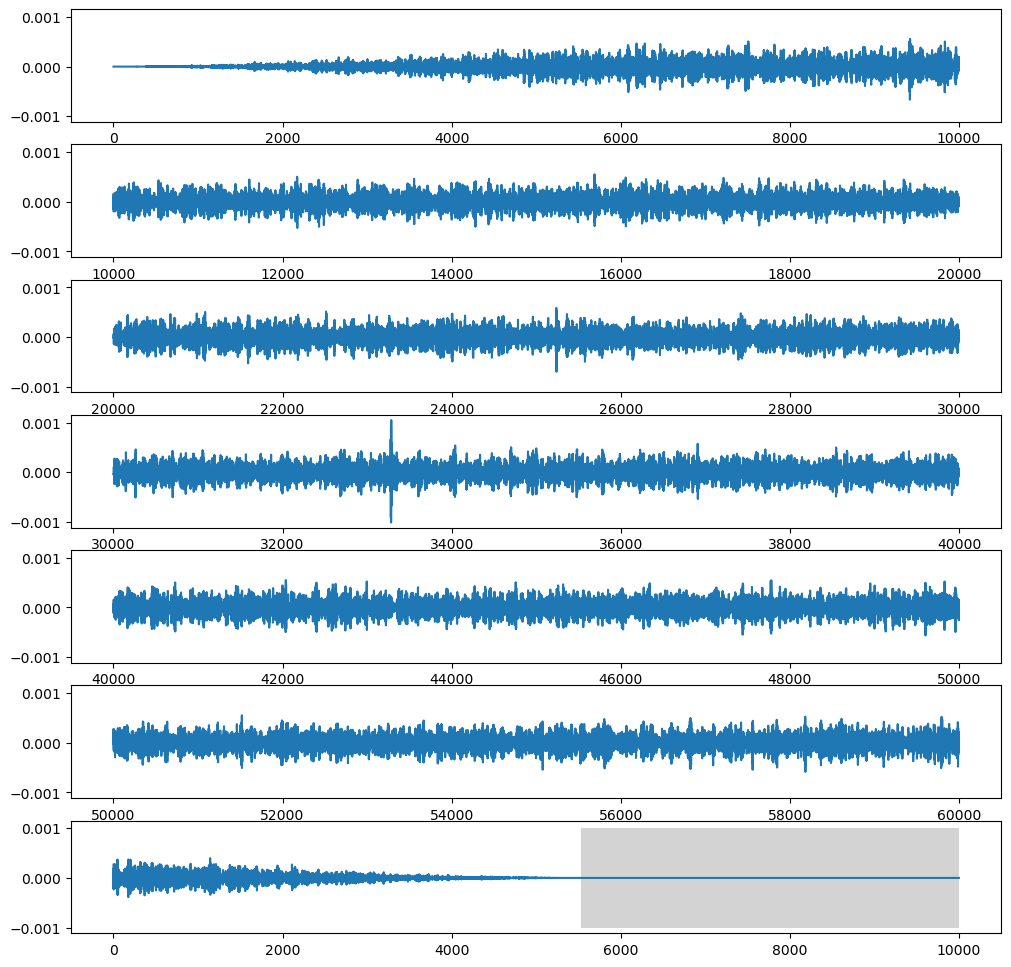

In [6]:
fig, axes = plt.subplots(nrows=7, ncols=1, figsize=(12,12), sharey=True)

for i in range(6):
    axes[i].plot(traces[10000*i:10000*(i+1)])
axes[6].plot(np.concatenate((traces[60000:], np.zeros(70000-len(traces))), axis=None))

rect = Rectangle((len(traces)-60000, -0.001), (70000-len(traces)),0.002, fc="lightgray")
axes[6].add_patch(rect)

plt.show()

In [7]:
# I should come up with a statistical measure
# traces_cut
tc = traces[6000:-6000].reset_index(drop=True).values.flatten()

In [8]:
maxamp = np.abs(tc).max()
cut = maxamp/2.3

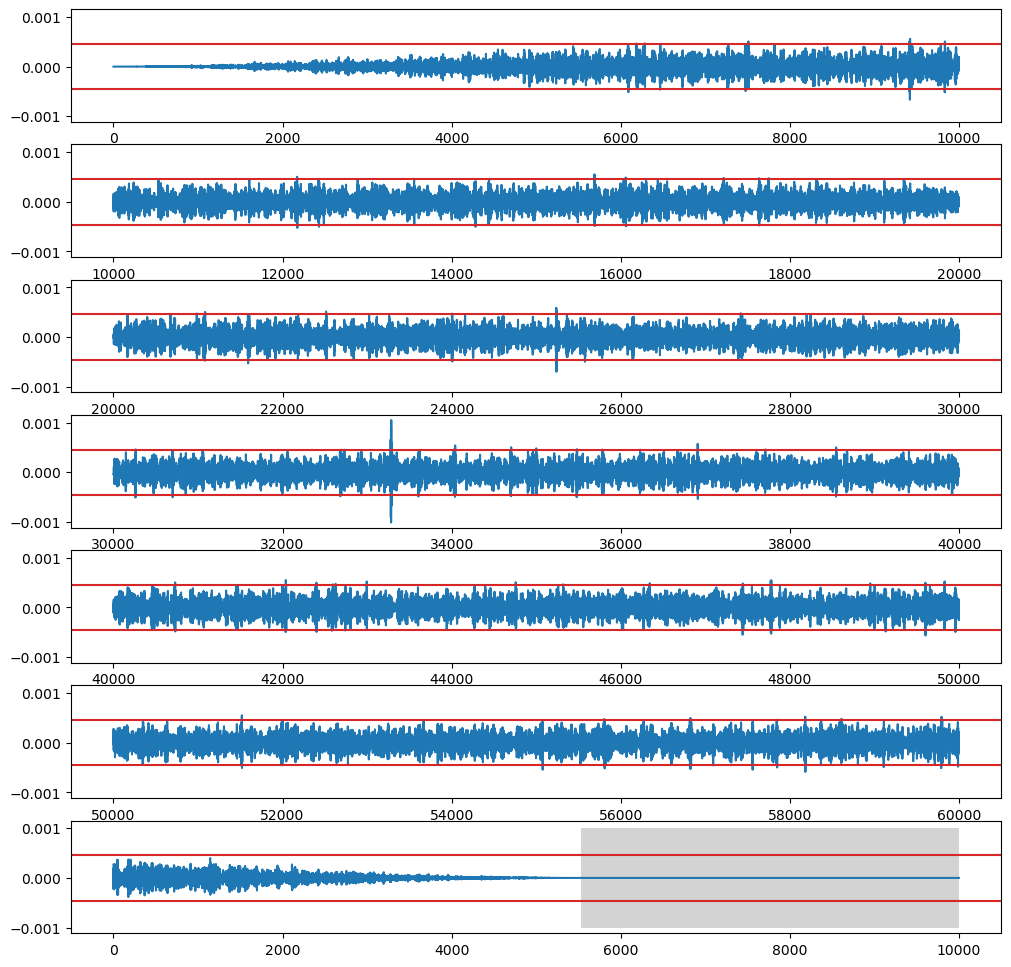

In [9]:
fig, axes = plt.subplots(nrows=7, ncols=1, figsize=(12,12), sharey=True)

for i in range(6):
    axes[i].plot(traces[10000*i:10000*(i+1)])
axes[6].plot(np.concatenate((traces[60000:], np.zeros(70000-len(traces))), axis=None))

rect = Rectangle((len(traces)-60000, -0.001), (70000-len(traces)),0.002, fc="lightgray")
axes[6].add_patch(rect)

for i in range(7):
    axes[i].axhline(y=cut, color="tab:red")
    axes[i].axhline(y=-cut, color="tab:red")

plt.show()

In [10]:
def get_real(trace, cut, duration, start):
    s = start
    while True:
        if s+duration >= len(trace):
            raise IndexError(f"Index exceeded: {s+duration}")
        real = trace[s:s+duration]
        if np.abs(real).max() < cut:
            break
        else:
            s = np.where(np.abs(real) >= cut)[0][-1]+1+s

    return real, s+duration


In [11]:
def get_reals(trace, cut, duration):
    s = 0
    reals = []
    while True:
        try:
            real, end = get_real(trace, cut, duration, s)
        except IndexError:
            break
        else:
            reals.append(real)
            s = end
    
    to_return = np.array(reals)
    print(f"Number of realizations: {len(to_return)}")
    return to_return

In [12]:
def make_cov(trace, cut, duration):
    reals = get_reals(trace, cut, duration)
    N = len(reals)

    if N==0:
        return np.zeros((duration, duration)), N
    
    mus = np.average(reals, axis=0)
    diffs = reals-mus

    cov = np.empty((duration, duration))
    for i in range(duration):
        for j in range(duration-i):
            cov[i, i+j] = np.sum(diffs[:,i]*diffs[:,j])/N
            cov[i+j,j] = cov[i,i+j]

    return cov, N


Number of realizations: 231


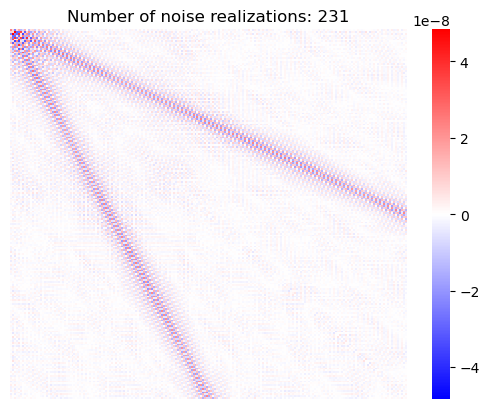

In [21]:
cov200, N = make_cov(tc, cut, 200)

sns.heatmap(cov200, xticklabels=False, yticklabels=False, cmap="bwr", norm=colors.CenteredNorm())
plt.title(f"Number of noise realizations: {N}")

plt.show()

Number of realizations: 231
Number of realizations: 72
Number of realizations: 26
Number of realizations: 9
Number of realizations: 164
Number of realizations: 26
Number of realizations: 1
Number of realizations: 0
Number of realizations: 75
Number of realizations: 2
Number of realizations: 0
Number of realizations: 0
Number of realizations: 14
Number of realizations: 0
Number of realizations: 0
Number of realizations: 0


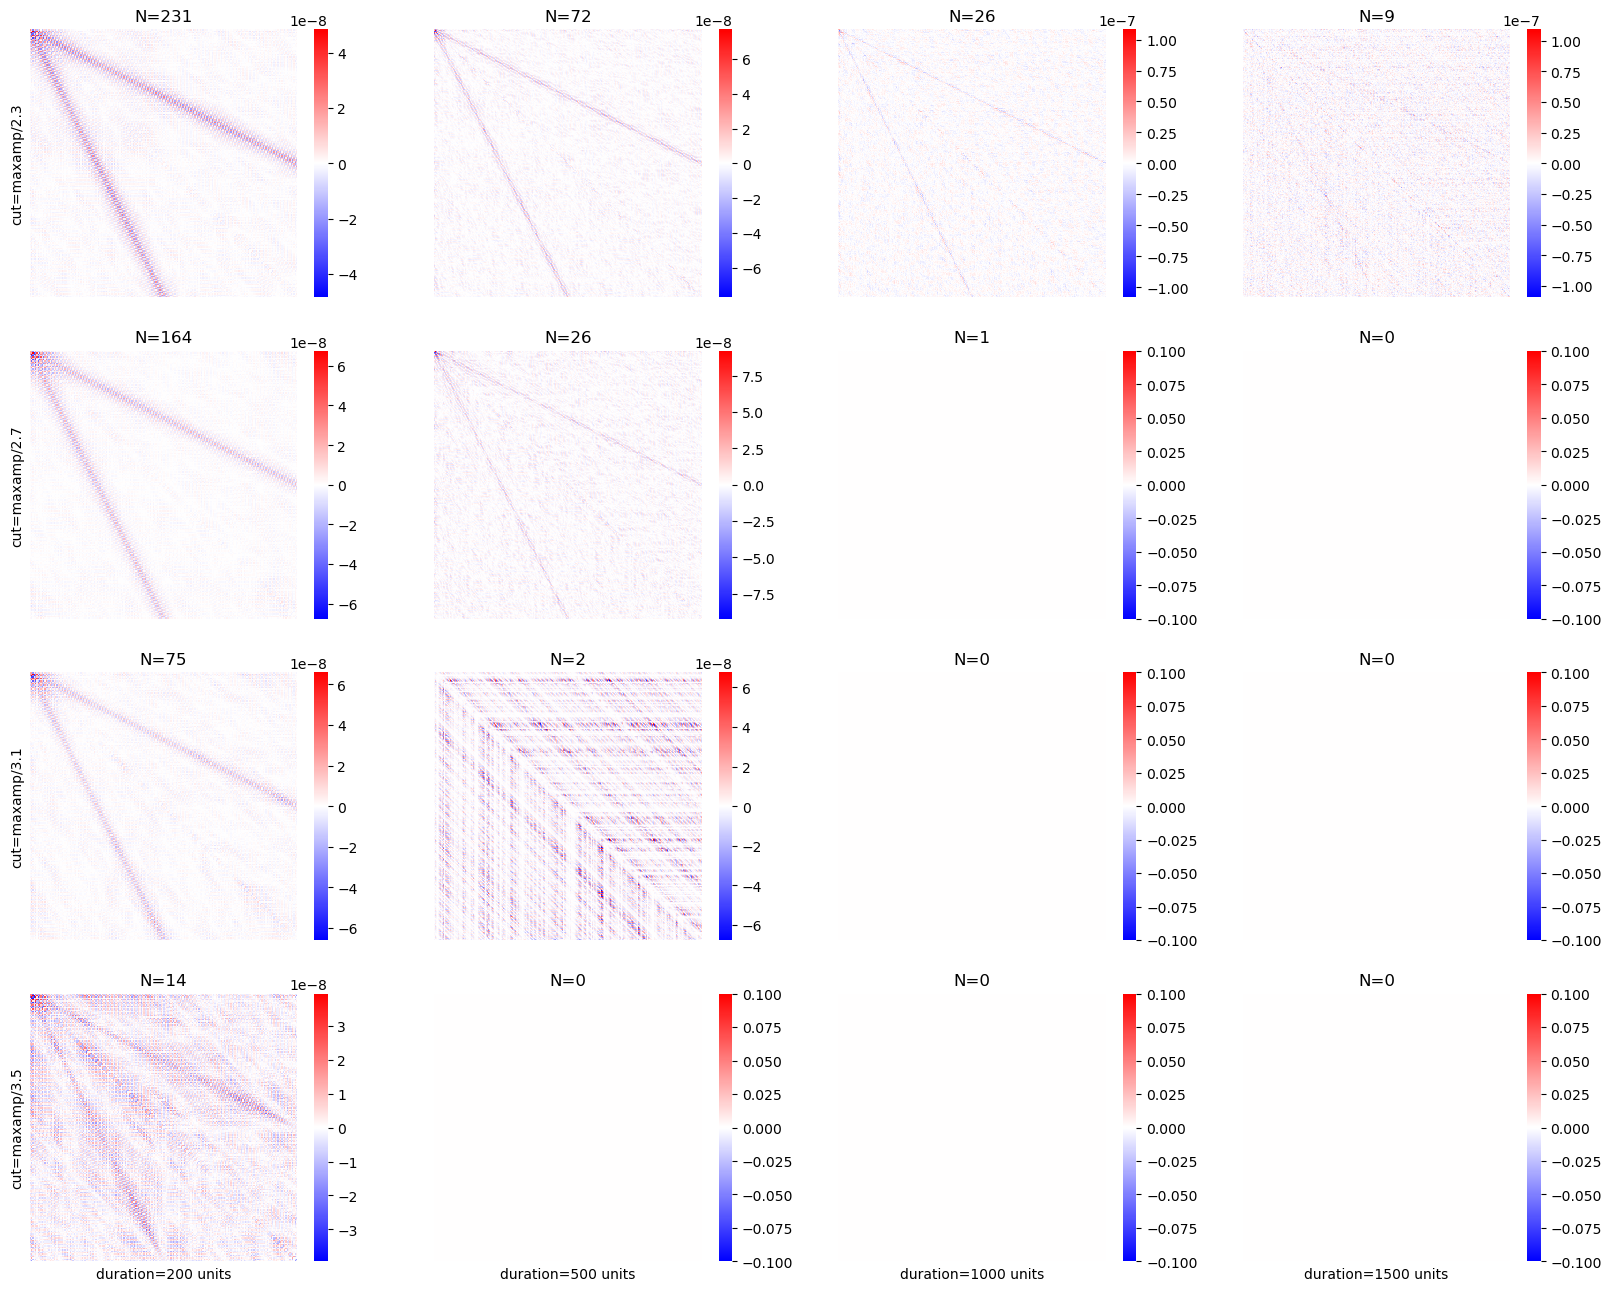

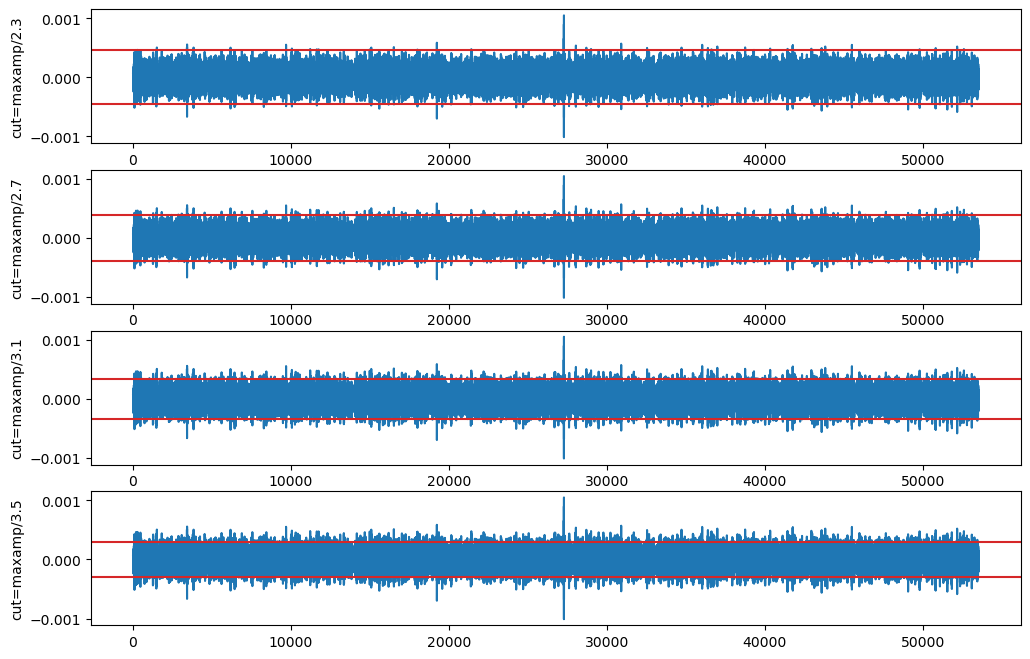

In [25]:
# try different values
tc = traces[6000:-6000].reset_index(drop=True).values.flatten()
maxamp = np.abs(tc).max()
ratios = np.array([2.3, 2.7, 3.1, 3.5])
cuts = maxamp/ratios
durs = np.array([200, 500, 1000, 1500])

cutsN = len(cuts)
dursN = len(durs)

fig, axes = plt.subplots(nrows=cutsN, ncols=dursN, figsize=(5*dursN, 4*cutsN))

for i in range(cutsN):
    for j in range(dursN):
        cov, N = make_cov(tc, cuts[i], durs[j])
        sns.heatmap(cov, xticklabels=False, yticklabels=False, ax=axes[i,j], square=True, cmap="bwr", norm=colors.CenteredNorm())
        # if N != 0:
        #     sns.heatmap(cov, xticklabels=False, yticklabels=False, ax=axes[i,j], square=True, cmap="bwr", norm=colors.CenteredNorm())
        # else:
        #     sns.heatmap(cov, xticklabels=False, yticklabels=False, ax=axes[i,j], square=True, cmap=["white"], linecolor="lightgray", linewidths=1, cbar=False)
        axes[i,j].set_title(f"N={N}")

        if i==cutsN-1:
            axes[cutsN-1, j].set_xlabel(f"duration={durs[j]} units")

    axes[i,0].set_ylabel(f"cut=maxamp/{ratios[i]}")

plt.show()
plt.close()

fig, axes = plt.subplots(nrows=cutsN, ncols=1, figsize=(12, 2*cutsN))

for i in range(cutsN):
    axes[i].plot(tc)
    axes[i].axhline(y=cuts[i], color="tab:red")
    axes[i].axhline(y=-cuts[i], color="tab:red")
    axes[i].set_ylabel(f"cut=maxamp/{ratios[i]}")

plt.show()
plt.close()


Number of realizations: 260
Number of realizations: 98
Number of realizations: 231
Number of realizations: 72


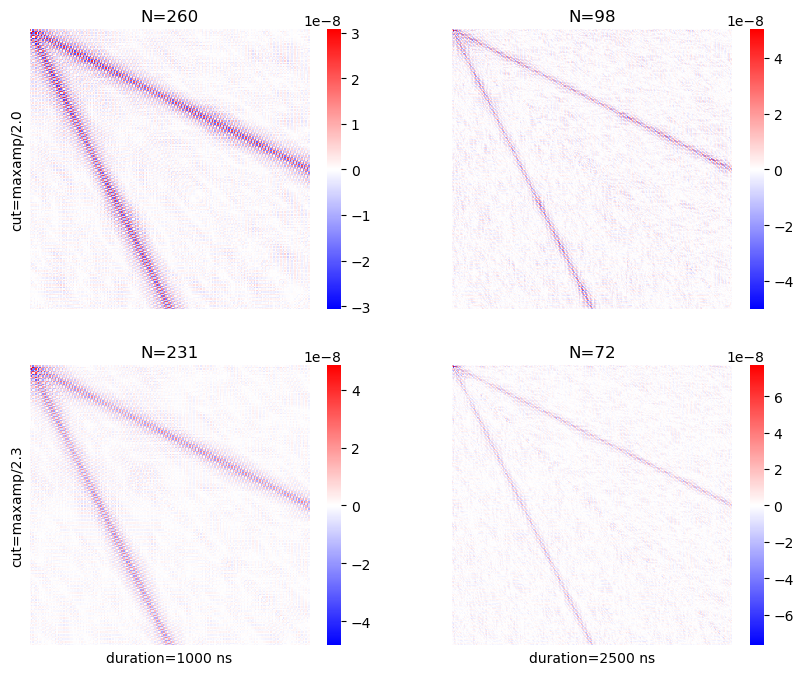

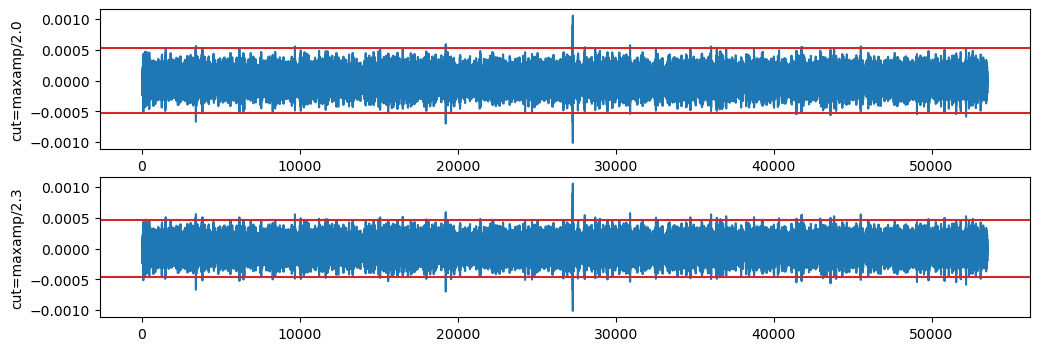

In [24]:
# Focus on top 2
tc = traces[6000:-6000].reset_index(drop=True).values.flatten()
maxamp = np.abs(tc).max()
ratios = np.array([2., 2.3])
cuts = maxamp/ratios
durs = np.array([200, 500])

cutsN = len(cuts)
dursN = len(durs)

fig, axes = plt.subplots(nrows=cutsN, ncols=dursN, figsize=(5*dursN, 4*cutsN))

for i in range(cutsN):
    for j in range(dursN):
        cov, N = make_cov(tc, cuts[i], durs[j])
        sns.heatmap(cov, xticklabels=False, yticklabels=False, ax=axes[i,j], square=True, cmap="bwr", norm=colors.CenteredNorm())
        axes[i,j].set_title(f"N={N}")

        if i==cutsN-1:
            axes[cutsN-1, j].set_xlabel(f"duration={durs[j]*5} ns")

    axes[i,0].set_ylabel(f"cut=maxamp/{ratios[i]}")

plt.show()
plt.close()

fig, axes = plt.subplots(nrows=cutsN, ncols=1, figsize=(12, 2*cutsN))

for i in range(cutsN):
    axes[i].plot(tc)
    axes[i].axhline(y=cuts[i], color="tab:red")
    axes[i].axhline(y=-cuts[i], color="tab:red")
    axes[i].set_ylabel(f"cut=maxamp/{ratios[i]}")

plt.show()
plt.close()
